In [109]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

Loading the dataset

In [20]:
data = pd.read_csv("../data/creditcard_fraud_detection.csv")
print(data.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [21]:
print(data.tail())

            Time         V1         V2        V3        V4        V5  \
284802  172786.0 -11.881118  10.071785 -9.834783 -2.066656 -5.364473   
284803  172787.0  -0.732789  -0.055080  2.035030 -0.738589  0.868229   
284804  172788.0   1.919565  -0.301254 -3.249640 -0.557828  2.630515   
284805  172788.0  -0.240440   0.530483  0.702510  0.689799 -0.377961   
284806  172792.0  -0.533413  -0.189733  0.703337 -0.506271 -0.012546   

              V6        V7        V8        V9  ...       V21       V22  \
284802 -2.606837 -4.918215  7.305334  1.914428  ...  0.213454  0.111864   
284803  1.058415  0.024330  0.294869  0.584800  ...  0.214205  0.924384   
284804  3.031260 -0.296827  0.708417  0.432454  ...  0.232045  0.578229   
284805  0.623708 -0.686180  0.679145  0.392087  ...  0.265245  0.800049   
284806 -0.649617  1.577006 -0.414650  0.486180  ...  0.261057  0.643078   

             V23       V24       V25       V26       V27       V28  Amount  \
284802  1.014480 -0.509348  1.436807  

Information of the data

In [22]:
print(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

Observing the columns

In [23]:
print(data.columns)

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')


Describing the data

In [24]:
print(data.describe())

                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.175161e-15  3.384974e-16 -1.379537e-15  2.094852e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   1.021879e-15  1.494498e-15 -5.620335e-16  1.149614e-16 -2.414189e-15   
std    1.380247e+00  1.332271e+00  1.23709

In [25]:
print(data.duplicated().sum())

1081


In [26]:
data.drop_duplicates(inplace=True)

Checking the number of valid and fraud

In [31]:
data['Class'].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

Checking the balance between the valid and fraud transactions

In [34]:
valid = data[data['Class'] == 0]
fraud = data[data['Class'] == 1]
outliner_fraction = len(fraud) / float(len(valid)) * 100

print(round(outliner_fraction, 2))

0.17


Plotting a graph

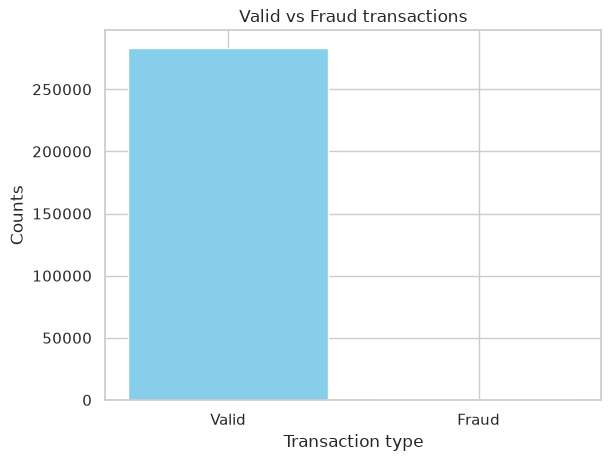

283253 473


In [90]:
valid_counts = len(data[data['Class'] == 0])
fraud_counts = len(data[data['Class'] == 1])

transactions = ['Valid', 'Fraud']
counts = [valid_counts, fraud_counts]
color = ['skyblue', 'salmon']

plt.bar(transactions, counts, color=color)
plt.title("Valid vs Fraud transactions")
plt.xlabel("Transaction type")
plt.ylabel("Counts")
plt.show()

print(valid_counts, fraud_counts)

Amount detailes of the fraud transactions

In [42]:
fraud.Amount.describe()

count     473.000000
mean      123.871860
std       260.211041
min         0.000000
25%         1.000000
50%         9.820000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

In [43]:
valid.Amount.describe()

count    283253.000000
mean         88.413575
std         250.379023
min           0.000000
25%           5.670000
50%          22.000000
75%          77.460000
max       25691.160000
Name: Amount, dtype: float64

Plotting avg amount graph

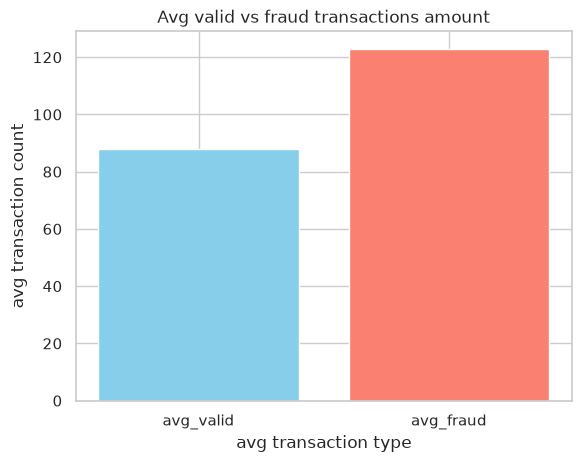

In [89]:
avg_valid = int(valid.Amount.mean())
avg_fraud = int(fraud.Amount.mean())

avg_transactions = ["avg_valid", "avg_fraud"]
avg_counts = [avg_valid, avg_fraud]
color = ['skyblue', 'salmon']

plt.bar(avg_transactions, avg_counts, color=color)
plt.title("Avg valid vs fraud transactions amount")
plt.xlabel("avg transaction type")
plt.ylabel("avg transaction count")
plt.show()

Splitting into training and testing data

In [53]:
X = data.drop(['Class'], axis=1)
y = data['Class']
print(X.shape)
print(y.shape)

X_data = X.values
y_data = y.values

x_train, x_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, random_state=42)

(283726, 30)
(283726,)


Checking accuracy in imbalance data in multimodel

In [110]:
models = {
    "Logistic Regression": LogisticRegression(solver='liblinear',max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss'),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Extra Tree": ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

result_list = []

print("Starting multimodel training...")

for model_name, model_obj in models.items():
    print(f"Training in {model_name}...")

    model_obj.fit(x_train, y_train)
    y_pred = model_obj.predict(x_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    result_list.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

df_comparison = pd.DataFrame(result_list)

df_comparison.set_index("Model", inplace=True)

print("MODEL COMPARISION")
print(df_comparison.round(4))

Starting multimodel training...
Training in Logistic Regression...
Training in Random Forest...
Training in XGBoost...
Training in Decision Tree...
Training in Extra Tree...
MODEL COMPARISION
                     Accuracy  Precision  Recall  F1 Score
Model                                                     
Logistic Regression    0.9990     0.7925  0.4667    0.5874
Random Forest          0.9995     0.9706  0.7333    0.8354
XGBoost                0.9952     0.0448  0.1000    0.0619
Decision Tree          0.9995     0.8933  0.7444    0.8121
Extra Tree             0.9996     0.9851  0.7333    0.8408


Graphically observing

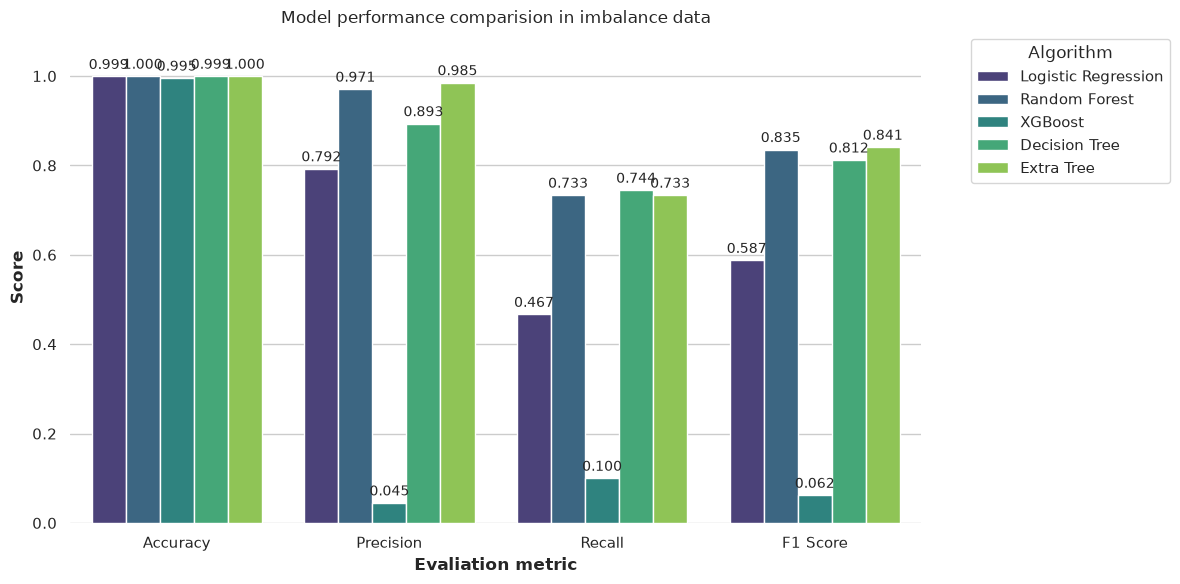

In [111]:
df_melted = df_comparison.reset_index().melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=df_melted,
    x="Metric",
    y="Score",
    hue="Model",
    palette="viridis"
)

plt.title("Model performance comparision in imbalance data")
plt.xlabel("Evaliation metric", fontsize=12, fontweight='bold')
plt.ylabel("Score", fontsize=12, fontweight='bold')
plt.ylim(0, 1.1)
plt.legend(title="Algorithm", bbox_to_anchor=(1.05, 1), loc='upper left')

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=10)

sns.despine(left=True, bottom=True)
plt.tight_layout()

plt.show()

Scailing the data

In [112]:
data["normAmount"] = StandardScaler().fit_transform(data["Amount"].values.reshape(-1, 1))
new_data = data.drop(['Time', 'Amount'], axis=1)

new_data.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Class,normAmount
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.244200
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.342584
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,1.158900
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.139886
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,-0.073813


Balancin the data using oversampling technique (SMOTE)

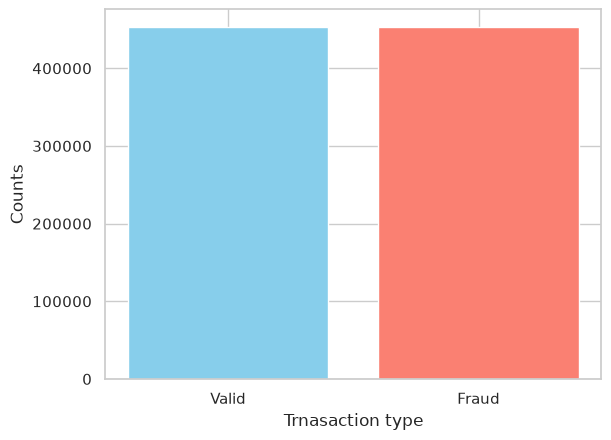

In [117]:
smote = SMOTE(sampling_strategy='minority', random_state=42)
x_train_sm, y_train_sm = smote.fit_resample(x_train, y_train)

fig, ax = plt.subplots()

valid_sm_count = len(x_train_sm)
fraud_sm_count = len(y_train_sm)

transaction_sm = ["Valid", "Fraud"]
sm_counts = [valid_sm_count, fraud_sm_count]

color = ['skyblue', 'salmon']
plt.bar(transaction_sm, sm_counts, color=color)
plt.xlabel("Trnasaction type")
plt.ylabel("Counts")
plt.show()


Training the balanced data using multimodel

In [118]:
print("Starting multimodel...")

result_list_sm = []

for sm_model_name, sm_model_obj in models.items():
    print(f"Starting model {sm_model_name}")

    sm_model_obj.fit(x_train_sm, y_train_sm)
    y_predict_sm = sm_model_obj.predict(x_test)

    accuracy = accuracy_score(y_test, y_predict_sm)
    precision = precision_score(y_test, y_predict_sm)
    recall = recall_score(y_test, y_predict_sm)
    f1 = f1_score(y_test, y_predict_sm)

    result_list_sm.append({
        "Model": sm_model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

df_comparison_sm = pd.DataFrame(result_list_sm)

df_comparison_sm.set_index("Model", inplace=True)

print("MODEL COMPARISION")
print(df_comparison_sm.round(4))

Starting multimodel...
Starting model Logistic Regression
Starting model Random Forest
Starting model XGBoost
Starting model Decision Tree
Starting model Extra Tree
MODEL COMPARISION
                     Accuracy  Precision  Recall  F1 Score
Model                                                     
Logistic Regression    0.9866     0.0914  0.8333    0.1647
Random Forest          0.9996     0.9467  0.7889    0.8606
XGBoost                0.9994     0.8182  0.8000    0.8090
Decision Tree          0.9814     0.0688  0.8556    0.1273
Extra Tree             0.9996     0.9459  0.7778    0.8537


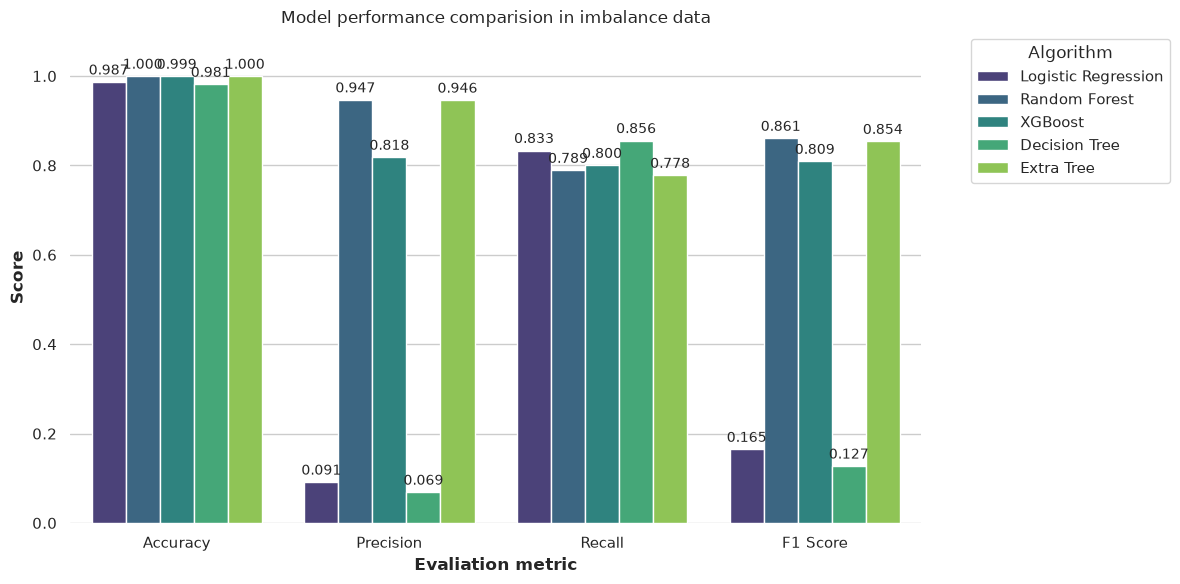

In [120]:
df_melted_sm = df_comparison_sm.reset_index().melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

ax_sm = sns.barplot(
    data=df_melted_sm,
    x="Metric",
    y="Score",
    hue="Model",
    palette="viridis"
)

plt.title("Model performance comparision in imbalance data")
plt.xlabel("Evaliation metric", fontsize=12, fontweight='bold')
plt.ylabel("Score", fontsize=12, fontweight='bold')
plt.ylim(0, 1.1)
plt.legend(title="Algorithm", bbox_to_anchor=(1.05, 1), loc='upper left')

for container in ax_sm.containers:
    ax_sm.bar_label(container, fmt='%.3f', padding=3, fontsize=10)

sns.despine(left=True, bottom=True)
plt.tight_layout()

plt.show()